## Overfitting and Data Augmentation

Data Augmentation is used to mitigate overfitting during training. Data Augmentation is used to simulate more variance in the training dataset by applying various types of transformations to the images. 

The concept is best described in Francois Chollet's book: Deep Learning with Python 2nd Edition (8.2.5).

"Overfitting is caused by having too few samples to learn from, rendering you unable to train a model that can generalize to new data. Given infinite data, your model would be exposed to every possible aspect of the data distribution at hand: you would never overfit. Data augmentation takes the approach of generating more training data from existing training samples by augmenting the samples via a number of random transformations that yield believable-looking images. The goal is that, at training time, your model will never see the exact same picture twice. This helps expose the model to more aspects of the data so it can generalize better."


In [1]:
import matplotlib.pyplot as plt
from keras import Model, Input, Sequential
from keras.layers import (
    Conv2D,
    MaxPool2D,
    Rescaling,
    Dense,
    Flatten,
    RandomFlip,
    RandomRotation,
    RandomZoom,
)

Classnames: 
0 baseball
1 basketball
2 beachballs
3 billiard ball
4 bowling ball
5 brass
6 buckeyballs
7 cannon ball
8 cricket ball
9 eyeballs


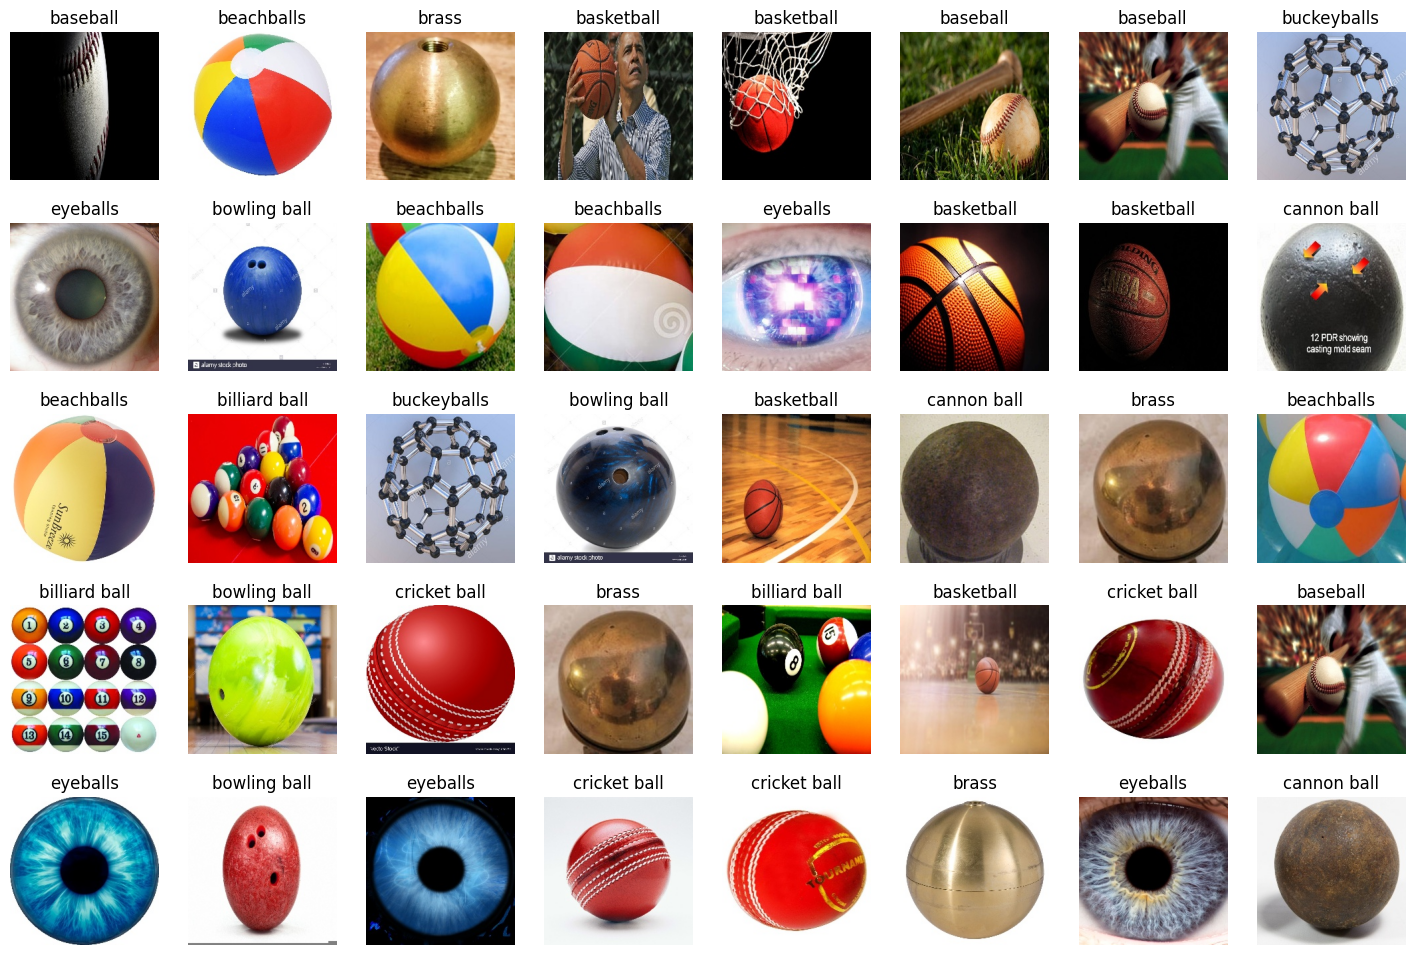

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.
Data batch shape: (64, 224, 224, 3)
Labels batch shape: (64, 10)
Take() Data batch shape: (64, 224, 224, 3)
Take() Labels batch shape: (64, 10)
['baseball', 'basketball', 'beachballs', 'billiard ball', 'bowling ball', 'brass', 'buckeyballs', 'cannon ball', 'cricket ball', 'eyeballs']


2025-11-27 14:54:21.401977: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


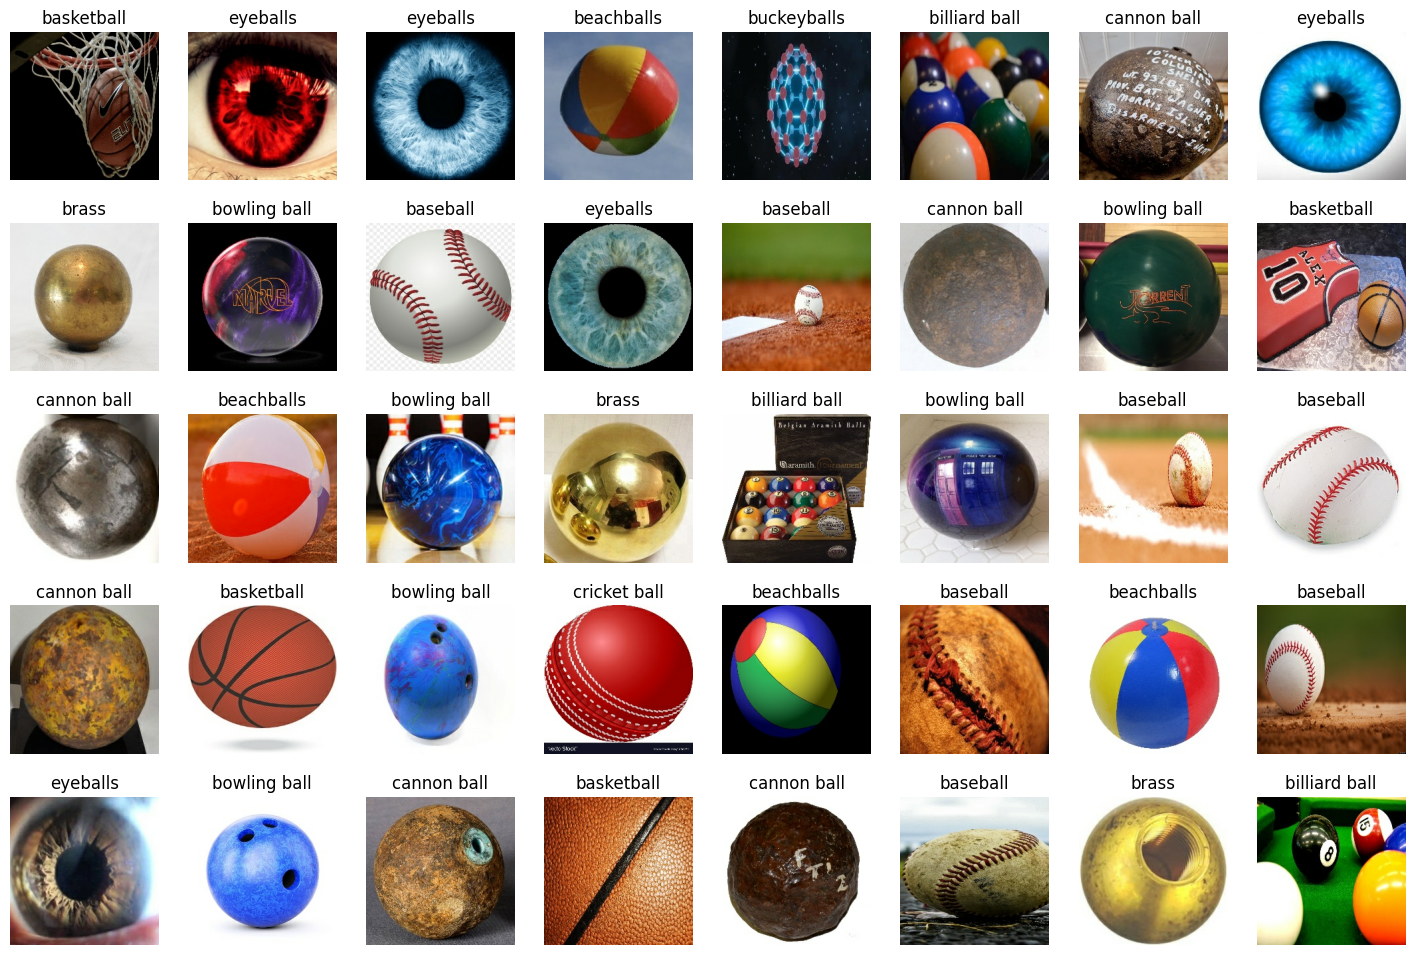

2025-11-27 14:54:22.270314: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
%run -i data_preprocessing.ipynb

In [3]:
# -------------------------------
# Define random transformations
# -------------------------------

# Rotation in either direction as a fraction of 2*PI
rand_rotation = RandomRotation(
    0.15,  # = .15 * 2 * PI = +/- 54 degrees
    fill_mode="nearest",  # Fill points outside boundaries with nearest pixel.
    seed=SEED,
)

# Horizontal Flipping
rand_flipping = RandomFlip(mode="horizontal", seed=SEED)

# Zooming
rand_zooming = RandomZoom(
    height_factor=(0.5, -0.5),  # Zooming In/Out up to 50% height
    width_factor=(0.5, -0.5),  # Zooming In/Out up to 50% width
    fill_mode="nearest",  # Fill points outside boundaries with nearest pixel.
    seed=SEED,
)

In [4]:
def augmentation_samples(dataset, augmentationPipeline, label=None):
    numPasses = 7
    plt.figure(figsize=(20, 5))

    for imagesBatch, _ in dataset.take(1):
        for i in range(numPasses):
            # Pass the imagesBatch through the augmntationPipeline
            augmentedImages = augmentationPipeline(imagesBatch)

            # Display the first image from the batch of augmented images
            ax = plt.subplot(1, numPasses, i + 1)
            plt.imshow(augmentedImages[15].numpy().astype("uint8"))
            plt.axis("off")

        break

    print("\n Augmentation Type: ", label)
    plt.show(block=False)


 Augmentation Type:  Rotation


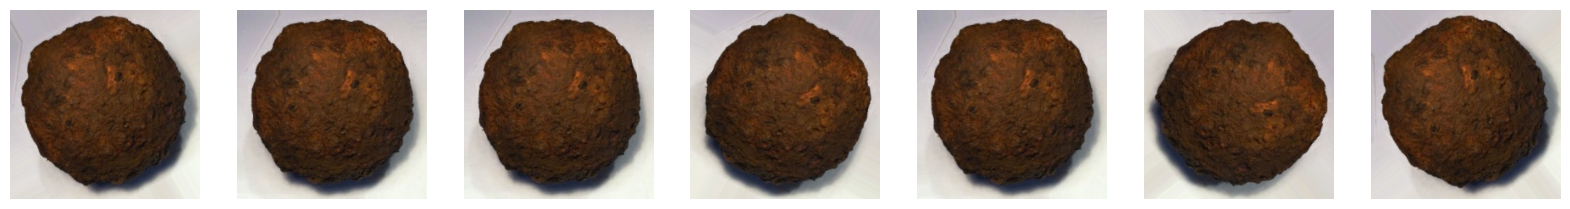


 Augmentation Type:  Zooming


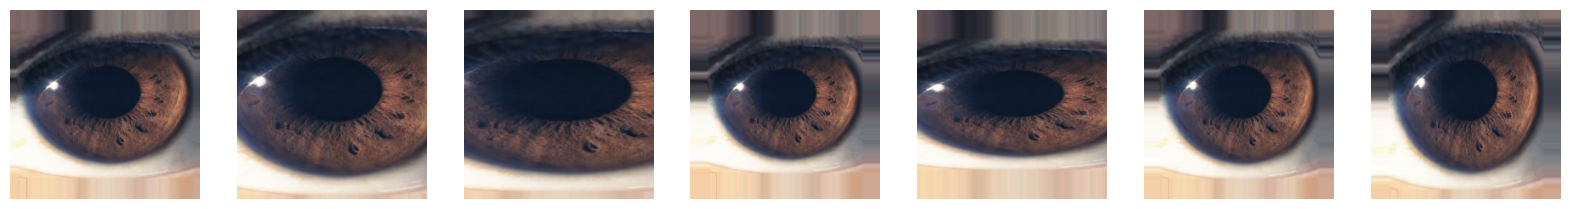


 Augmentation Type:  Flipping


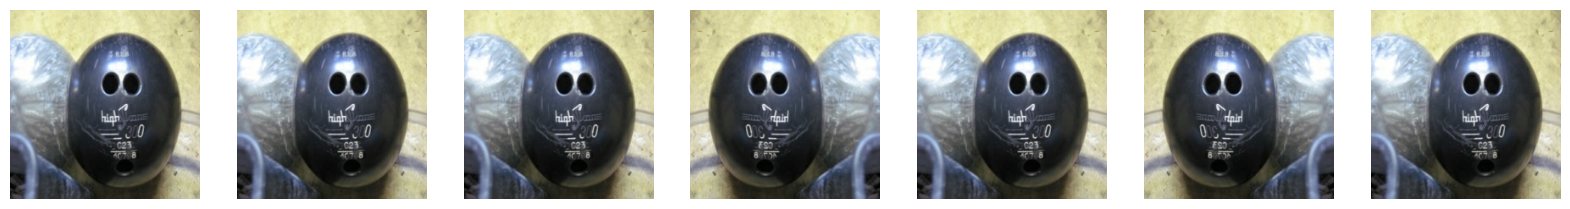

In [5]:
augmentation_samples(train_dataset, rand_rotation, "Rotation")
augmentation_samples(train_dataset, rand_zooming, "Zooming")
augmentation_samples(train_dataset, rand_flipping, "Flipping")

## Keras Augmentation Pipeline

Create a data augmentation pipeline using the Keras Sequential API to string together multiple transformations.

In [6]:
data_augmentation_layer = Sequential(
    [
        rand_rotation,
        rand_flipping,
        rand_zooming,
    ]
)

In [7]:
def display_augmentation_grid(dataset, dataAugmentationPipeline):
    num_rows = 4
    num_cols = 5
    num_passes = num_rows * num_cols
    plt.figure(figsize=(20, 13))

    for image_batch, _ in dataset.take(1):
        for i in range(num_passes):
            # Pass the image_batch through the augmentation pipeline.
            augmented_images = dataAugmentationPipeline(image_batch)

            # Display just the first augmented image from the batch of augmented images.
            ax = plt.subplot(num_rows, num_cols, i + 1)
            plt.imshow(augmented_images[54].numpy().astype("uint8"))
            plt.axis("off")

    plt.show(block=False)

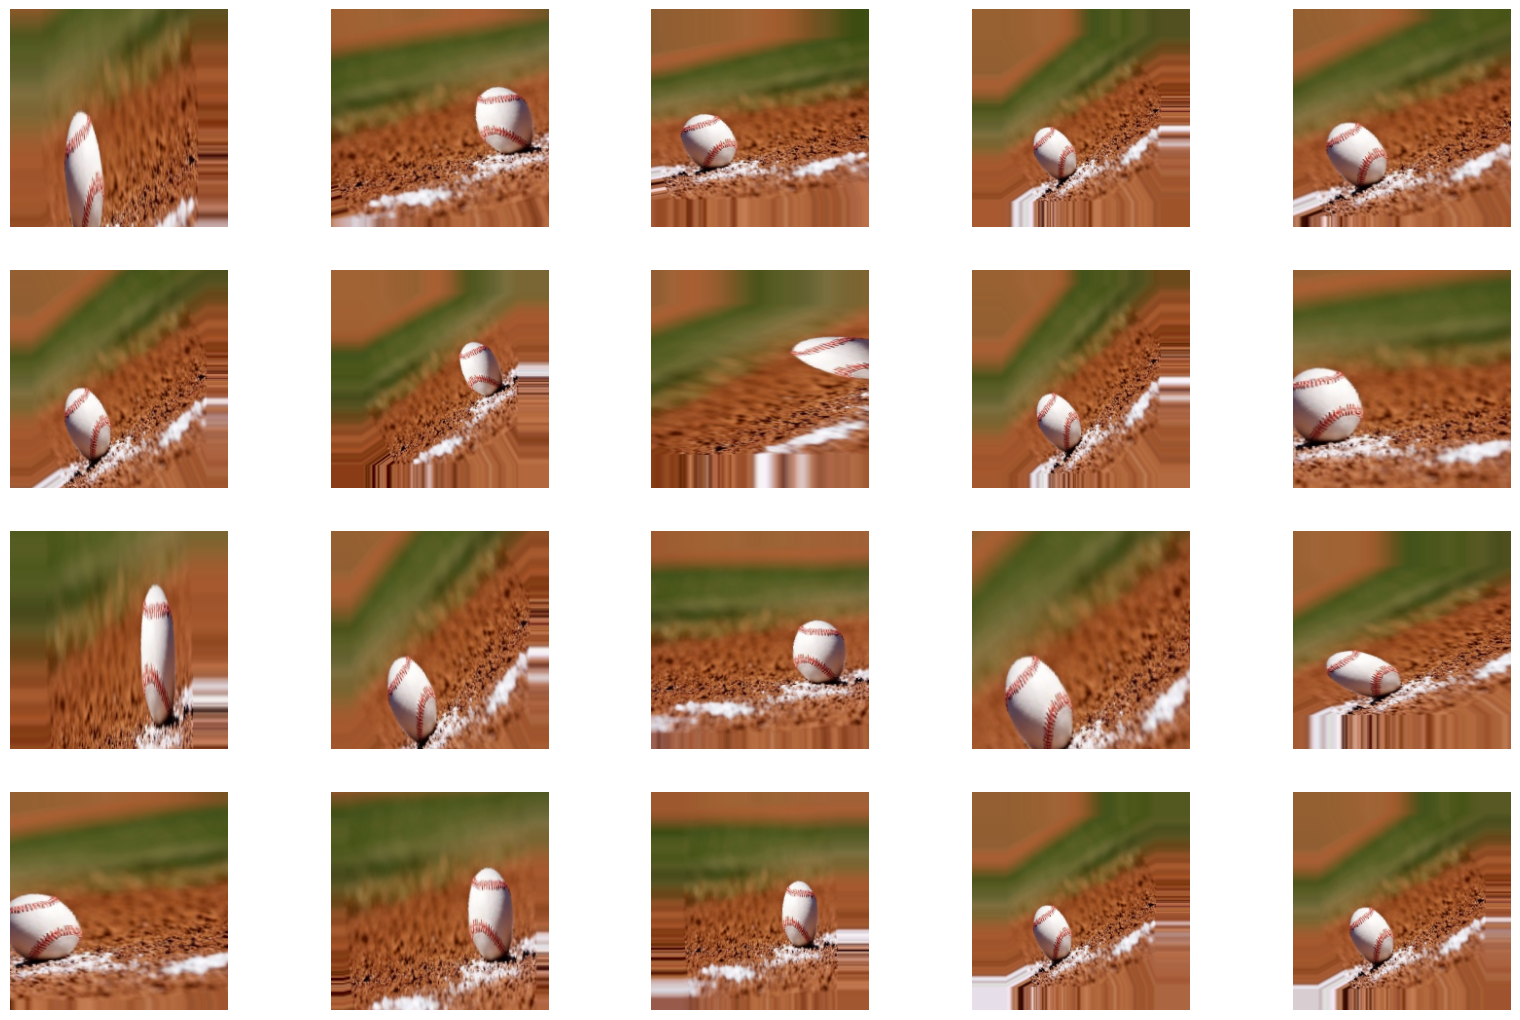

In [8]:
display_augmentation_grid(train_dataset, data_augmentation_layer)

## Model with Data Augmentation Layer

For every batch of images in the training set, the data augmentation layer applies the random transformations defined in the data augmentation pipeline, so that the data used during each training epoch has been randomized. In other words, during each epoch, the model is trained on a slightly different set of data than previous epochs, which introduces more variance in the training data and helps the model generalize better, which mitigates overfitting.

In [9]:
def augmentedCNNModel(inputShape=(224, 224, 3), numClasses=10):
    inputs = Input(shape=inputShape)

    # ----------------------
    # Data Pre-processing
    # ----------------------
    x = data_augmentation_layer(inputs)
    x = Rescaling(1.0 / 255)(x)

    # BODY (Feature Extractor)
    # -------------------------------
    # Conv Block 1: 32-32-MaxPool.
    # -------------------------------
    x = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 2: 64-64-MaxPool.
    # -------------------------------
    x = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 3: 128-128-MaxPool.
    # -------------------------------
    x = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # -------------------------------
    # Conv Block 3: 256-256-MaxPool.
    # -------------------------------
    x = Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(x)
    x = MaxPool2D(pool_size=2, strides=2)(x)

    # Head
    # -------------------------------
    # Fully conneted layers.
    # -------------------------------
    x = Flatten()(x)

    x = Dense(512, activation="relu")(x)
    outputs = Dense(numClasses, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model

In [10]:
model = augmentedCNNModel(
    inputShape=(
        datasetConfig.IMG_HEIGHT,
        datasetConfig.IMG_WIDTH,
        datasetConfig.NUM_CHANNELS,
    ),
    numClasses=datasetConfig.NUM_CLASSES,
)

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,868,010 (102.49 MB)

 Trainable params: 26,868,010 (102.49 MB)

 Non-trainable params: 0 (0.00 B)

None
